In [1]:
#bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
# Carregar dataset
path = "D:/OneDriveBackup/OneDrive - Claro SA/LAURA SILVA SOARES DE MELO/arquivos/projetos/projeto_conectividade/data/br_anatel_indice_brasileiro_conectividade_municipio.csv"
df = pd.read_csv(path, encoding='utf-8')

In [3]:
#Mostrar primeiras linhas
print("\nPrimeiras linhas do dataset:")
print(df.head())


Primeiras linhas do dataset:
    ano sigla_uf  id_municipio    ibc  cobertura_pop_4g5g  fibra  \
0  2024       RO       1100296  49.92             62.9831    100   
1  2024       AC       1200351  16.28             30.3470      0   
2  2024       AM       1300839  29.17             50.9133     50   
3  2024       AM       1302207  20.06             53.3310      0   
4  2024       PA       1501204  34.08             52.8200    100   

   densidade_smp  hhi_smp  densidade_scm  hhi_scm  adensamento_estacoes  
0          44.00       51          23.87       47                 25.39  
1          36.72       16           8.04       33                  8.36  
2          26.62        7           0.65       71                 17.47  
3          36.33       36           5.85       19                 13.45  
4          20.46       15           2.85       52                  6.26  


In [4]:
#Municípios com baixa fibra mas alta cobertura 4G/5G podem ser priorizados para expansão
# Criar coluna de diferença entre cobertura móvel e fibra
df["gap_fibra_vs_movel"] = df["cobertura_pop_4g5g"] - df["fibra"]

prioritarios = df[
    (df["fibra"] < 30) &
    (df["cobertura_pop_4g5g"] > 70)
].sort_values("gap_fibra_vs_movel", ascending=False)

prioritarios.head()


,ano,sigla_uf,id_municipio,ibc,cobertura_pop_4g5g,fibra,densidade_smp,hhi_smp,densidade_scm,hhi_scm,adensamento_estacoes,gap_fibra_vs_movel
3833,2022,PB,2512721,32.07,100.0,0,63.47,8,5.01,7,8.67,100.0
4177,2023,PE,2605459,53.62,100.0,0,90.88,82,23.70,66,46.03,100.0
4523,2024,RN,2413201,57.02,100.0,0,67.41,59,18.24,66,59.62,100.0
4754,2022,PE,2604403,35.58,100.0,0,64.03,67,2.76,17,6.42,100.0
2485,2022,RN,2401206,31.68,100.0,0,44.30,12,0.58,79,5.03,100.0


In [ ]:
#Estatísticas gerais
print("\nResumo estatístico:")
print(df.describe())


Resumo estatístico:
                ano  id_municipio           ibc  cobertura_pop_4g5g  \
count  22280.000000  2.228000e+04  22280.000000        22280.000000   
mean    2022.500000  3.253591e+06     51.906346           80.004675   
std        1.118059  9.848440e+05     13.865064           18.047806   
min     2021.000000  1.100015e+06      9.810000            0.000000   
25%     2021.750000  2.512101e+06     43.140000           68.548075   
50%     2022.500000  3.146280e+06     54.310000           84.711650   
75%     2023.250000  4.119202e+06     62.292500           95.494500   
max     2024.000000  5.300108e+06     94.570000          120.030900   

              fibra  densidade_smp       hhi_smp  densidade_scm       hhi_scm  \
count  22280.000000   22280.000000  22280.000000   22280.000000  22280.000000   
mean      76.216338      59.923873     47.390619      16.617638     56.186131   
std       40.896435      19.343919     25.059560      17.417516     20.941347   
min        0.00

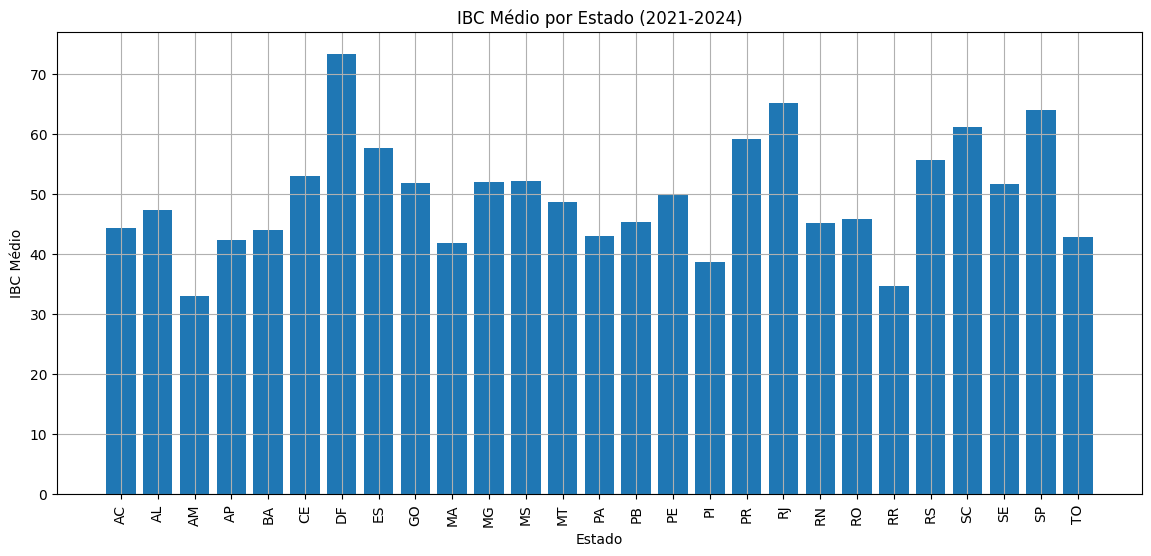

In [6]:
#IBC por estado (média)
df_estado = df.groupby("sigla_uf")["ibc"].mean().reset_index()

# Gráfico de barras
plt.figure(figsize=(14,6))
plt.bar(df_estado["sigla_uf"], df_estado["ibc"])
plt.title("IBC Médio por Estado (2021-2024)")
plt.xlabel("Estado")
plt.ylabel("IBC Médio")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()



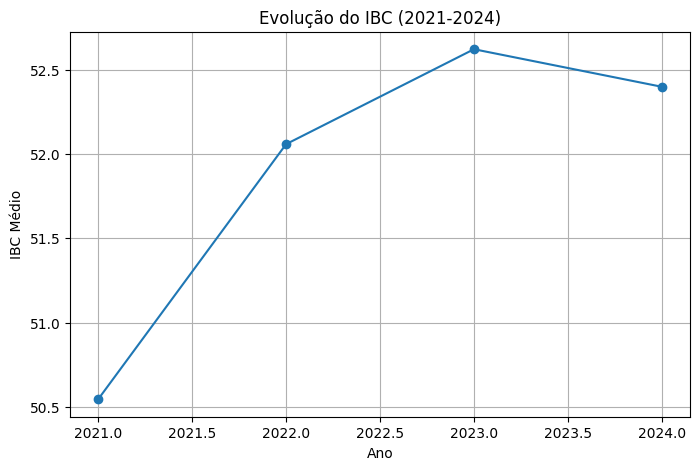

In [7]:
#Evolução do IBC ao longo dos anos
df_ano = df.groupby("ano")["ibc"].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(df_ano["ano"], df_ano["ibc"], marker="o")
plt.title("Evolução do IBC (2021-2024)")
plt.xlabel("Ano")
plt.ylabel("IBC Médio")
plt.grid(True)
plt.show()
